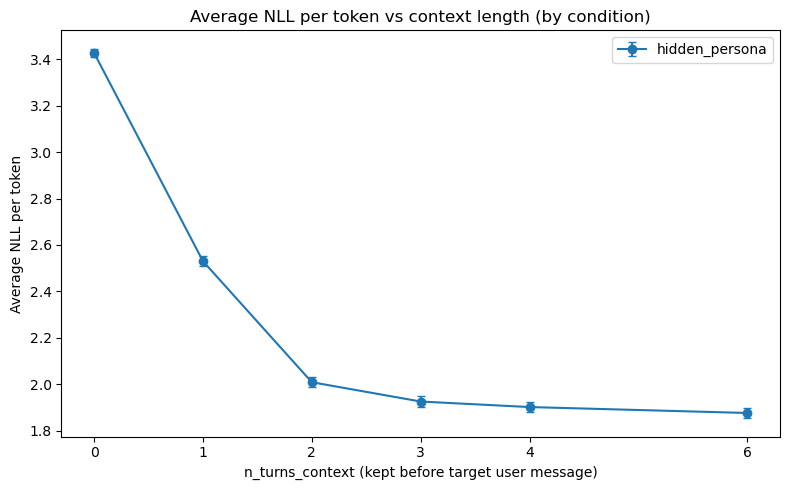

,condition,n_turns_context,mean_nll,std_nll,n,sem_nll
0,hidden_persona,0,3.427907,0.552816,1000,0.017482
1,hidden_persona,1,2.529937,0.659429,1000,0.020853
2,hidden_persona,2,2.008160,0.702456,1000,0.022214
3,hidden_persona,3,1.924866,0.694804,1000,0.021972
4,hidden_persona,4,1.901088,0.692823,1000,0.021909
5,hidden_persona,6,1.875554,0.700336,1000,0.022147


In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Set this to your actual file ===
scores_path = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/src/data/scores/stitched_scores_20260204_103909.jsonl"  

# ---------- Load JSONL ----------
rows = []
with open(scores_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# ---------- Compute NLL per token ----------
# avg_logprob is mean log p(token | context), so NLL/token = -avg_logprob
df["nll_per_token"] = -df["avg_logprob"]

# basic cleaning
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["nll_per_token", "n_turns_context", "condition"])

# ---------- Aggregate: mean + SEM ----------
agg = (
    df.groupby(["condition", "n_turns_context"], as_index=False)
      .agg(mean_nll=("nll_per_token", "mean"),
           std_nll=("nll_per_token", "std"),
           n=("nll_per_token", "count"))
)
agg["sem_nll"] = agg["std_nll"] / np.sqrt(agg["n"].clip(lower=1))

# ---------- Plot ----------
plt.figure(figsize=(8, 5))

for cond, sub in agg.groupby("condition"):
    sub = sub.sort_values("n_turns_context")
    plt.errorbar(
        sub["n_turns_context"],
        sub["mean_nll"],
        yerr=sub["sem_nll"],
        marker="o",
        capsize=3,
        label=cond,
    )

plt.xlabel("n_turns_context (kept before target user message)")
plt.ylabel("Average NLL per token")
plt.title("Average NLL per token vs context length (by condition)")
plt.xticks(sorted(df["n_turns_context"].unique()))
plt.legend()
plt.tight_layout()
plt.show()

# (optional) show the table
agg.sort_values(["condition", "n_turns_context"])
